<div style="text-align: center;">
<h1 style="font-weight: bold; margin: 20px 0;">
UKSEDS Training - Monitoring climate change with satellite-derived data</h1>
</div>


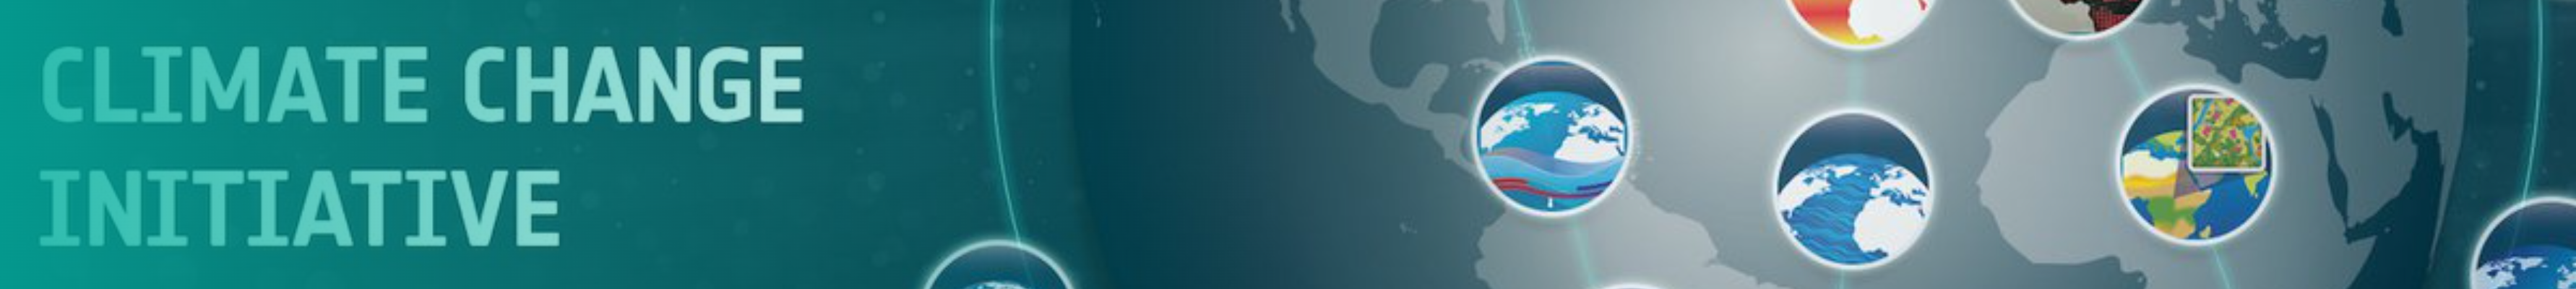

<div style="background-color: #96D7EB;  padding: 10px; border-left: 5px solid #96D7EB;">
<h2 style="margin: 0 0 15px 0; font-size: 1.4em;">1. Introduction:</h2>

In this beginner-friendly notebook, we will use real satellite-based data from the [ESA Climate Change Initiative (CCI)](https://climate.esa.int/en/odp/#/dashboard) to explore recent climate trends.
For more information on how these datasets are produces, have a look at our Webinars Series - Monitoring climate change from space : https://climate.esa.int/en/climate-change-initiative-training/webinars/

<h2 style="margin: 0 0 15px 0; font-size: 1.4em;">Learning Objectives:</h2>

We will use simple Python code and visualisations to explore questions such as:

* *Has land surface temperature increased over the last decades in London?*
* *What differences can we observe between rural and urban areas?*

This notebook is designed for **participants with no prior experience in Python or climate data analysis**. You will learn:

- How to access CCI climate data using the CCI Toolbox python Package
- How to navigate and subset climate data using Xarray
- How to create basic plots and statistics with Matplotlib
- How to save a figure you generated
- How to map and interpret ECVs changes over time and space
</div>

## Step 1. Setup & Imports

Before we can start working with the data, we need to import a few Python libraries. These libraries provide useful tools for working with satellite data, performing simple calculations, and creating visualizations.

Don’t worry if you’re not familiar with these yet — we’ll explain what you need as we go.

In [1]:
# ESA Climate Toolbox imports for accessing and plotting ESA CCI data
from esa_climate_toolbox.core import get_op              # Get predefined operations (e.g., time series, averages)
from esa_climate_toolbox.core import list_ecv_datasets   # List available datasets per ECV (Essential Climate Variable)
from esa_climate_toolbox.core import get_store           # Connect to an ESA data store
from esa_climate_toolbox.core import list_datasets       # List all datasets in a store
from esa_climate_toolbox.core import search
from esa_climate_toolbox.ops import plot                 # High-level plotting functions for CCI data

# Used for connecting to remote data sources (e.g., ESA CCI ODP)
from xcube.core.store import new_data_store

# For displaying geographic regions interactively (if desired)
from IPython.display import GeoJSON
import shapely.geometry   # Handling geometric objects like bounding boxes

# Core data science libraries
import pandas as pd       # For tabular data handling and time manipulation
import numpy as np        # For numerical operations
import xarray as xr       # For multi-dimensional climate data structures

# Mapping and plotting
import matplotlib.pyplot as plt       # Plotting library
import cartopy.crs as ccrs            # Cartographic projections for spatial data
import IPython.display 

# Notebook settings
import warnings
warnings.filterwarnings("ignore") # Suppressing warnings to keep notebook output clean
%matplotlib inline

**What we just did:**

* `numpy`: helps with numbers and arrays.
* `matplotlib`: lets us create plots and maps.
* `xarray`: makes it easy to work with climate datasets.
* `cartopy`: helps plot maps with geographic context.
* `Toolbox`: a package that facilitates access and computation of CCI data

Up next: We’ll learn how to **access ECVs** from the CCI Toolbox.

## Step 2: Load & Visualize Global LST
### Define the Dataset ID
To work with a specific ESA CCI dataset, we need to specify its **dataset ID**. This unique identifier tells the toolbox which variable and product we want to access.

In this section, we are using a the sea surface temperature (LST) zarr file. You can find the variables of the products under **data_vars**. For the LST, we will use the variable **analysed_LST**. 

First, we define the dataset ID and the store from which we retrieve the data (for the LST it is `esa-cci-zarr`). For this notebook we will focus on this dat With the command `describe_data`, we can have a look at the structure of the file, such as time, dimension and the variable stored within.

In [2]:
#list_datasets()

In [3]:
list_ecv_datasets("LST")

[('esacci.LST.3-hours.L3S.LST.multi-sensor.multi-platform.IRMGP.1-00.r1',
  'esa-cci'),
 ('esacci.LST.3-hours.L3S.LST.multi-sensor.multi-platform.IRMGP.3-00.00:00UTC',
  'esa-cci'),
 ('esacci.LST.3-hours.L3S.LST.multi-sensor.multi-platform.IRMGP.3-00.03:00UTC',
  'esa-cci'),
 ('esacci.LST.3-hours.L3S.LST.multi-sensor.multi-platform.IRMGP.3-00.06:00UTC',
  'esa-cci'),
 ('esacci.LST.3-hours.L3S.LST.multi-sensor.multi-platform.IRMGP.3-00.09:00UTC',
  'esa-cci'),
 ('esacci.LST.3-hours.L3S.LST.multi-sensor.multi-platform.IRMGP.3-00.12:00UTC',
  'esa-cci'),
 ('esacci.LST.3-hours.L3S.LST.multi-sensor.multi-platform.IRMGP.3-00.15:00UTC',
  'esa-cci'),
 ('esacci.LST.3-hours.L3S.LST.multi-sensor.multi-platform.IRMGP.3-00.18:00UTC',
  'esa-cci'),
 ('esacci.LST.3-hours.L3S.LST.multi-sensor.multi-platform.IRMGP.3-00.21:00UTC',
  'esa-cci'),
 ('esacci.LST.day.L3C.LST.AATSR.Envisat.ATSR_3.3-00.DAY', 'esa-cci'),
 ('esacci.LST.day.L3C.LST.AATSR.Envisat.ATSR_3.3-00.NIGHT', 'esa-cci'),
 ('esacci.LST.day.

In [4]:
# Open the ESA CCI zarr store
cci_zarr_store = new_data_store("esa-cci-zarr")

In [5]:
# Which data do we have in the ESA CCI zarr store ?
list_datasets("esa-cci-zarr")

['ESACCI-BIOMASS-L4-AGB-MERGED-100m-2010-2018-fv2.0.zarr',
 'ESACCI-BIOMASS-L4-AGB-MERGED-100m-2010-2020-fv4.0.zarr',
 'ESACCI-GHG-L2-CH4-SCIAMACHY-WFMD-2002-2011-fv1.zarr',
 'ESACCI-GHG-L2-CO2-OCO-2-FOCAL-2014-2021-v10.zarr',
 'ESACCI-GHG-L2-CO2-SCIAMACHY-WFMD-2002-2012-fv1.zarr',
 'ESACCI-ICESHEETS_Antarctica_GMB-2002-2016-v1.1.zarr',
 'ESACCI-ICESHEETS_Greenland_GMB-2003-2016-v1.1.zarr',
 'ESACCI-L3C_CLOUD-CLD_PRODUCTS-AVHRR_NOAA-1982-2016-fv3.0.zarr',
 'ESACCI-L3C_SNOW-SWE-1979-2018-fv1.0.zarr',
 'ESACCI-L3C_SNOW-SWE-1979-2020-fv2.0.zarr',
 'ESACCI-L4_FIRE-BA-MODIS-2001-2022-fv5.1.zarr',
 'ESACCI-L4_GHRSST-SST-GMPE-GLOB_CDR2.0-1981-2016-v02.0-fv01.0.zarr',
 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-2015-v2.0.7b.zarr',
 'ESACCI-LST-L3C-LST-MODISA-0.01deg_1DAILY_DAY-2002-2018-fv3.00.zarr',
 'ESACCI-LST-L3C-LST-MODISA-0.01deg_1DAILY_NIGHT-2002-2018-fv3.00.zarr',
 'ESACCI-LST-L3S-LST-IRCDR_-0.01deg_1DAILY_DAY-1995-2020-fv3.00.zarr',
 'ESACCI-LST-L3S-LST-IRCDR_-0.01deg_1DAILY_NIGHT-1995-2020

In [6]:
data_id ='ESACCI-LST-L3S-LST-IRCDR_-0.01deg_1MONTHLY_DAY-1995-2020-fv3.00.zarr'

### Describe Dataset (Check Available Variables and Metadata)

Before loading the full dataset, it’s helpful to **inspect the metadata** to understand its structure. This includes:

- Available variables (e.g., LST, uncertainty estimates)
- Temporal and spatial coverage
- Data format and structure

This step ensures we know what the dataset contains and how to work with it. It also helps confirm that the variable we want to plot or analyze is actually included.

🛠️ Tip: You can use the description to verify variable names, dimensions (e.g., `lat`, `lon`, `time`), and time coverage.

📘 More on dataset structure:  
🔗 [ESA Climate Toolbox – Data Access](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#accessing-data)

In [7]:
# Open the ESA CCI zarr store
cci_zarr_store.describe_data(data_id)

In [8]:
#open the LST dataset
LST_ds = cci_zarr_store.open_data(
    data_id=data_id)
display(LST_ds)

<xarray.Dataset> Size: 18TB
Dimensions:          (channel: 2, time: 294, lat: 18000, lon: 36000,
                      length_scale: 294)
Coordinates:
  * channel          (channel) float64 16B 11.0 12.0
  * lat              (lat) float32 72kB -90.0 -89.99 -89.98 ... 89.98 89.99
  * lon              (lon) float32 144kB -180.0 -180.0 -180.0 ... 180.0 180.0
  * time             (time) datetime64[ns] 2kB 1995-08-01 ... 2020-12-01
Dimensions without coordinates: length_scale
Data variables: (12/14)
    dtime            (time, lat, lon) timedelta64[ns] 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    lcc              (time, lat, lon) float32 762GB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    lst              (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    lst_unc_loc_atm  (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    lst_unc_loc_cor  (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    lst_unc_loc_sfc  (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    ...               ...
    lst_uncertainty  (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    n                (time, lat, lon) float32 762GB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    sataz            (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    satze            (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    solaz            (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    solze            (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
Attributes: (12/42)
    Conventions:                CF-1.8
    catalogue_url:              https://catalogue.ceda.ac.uk/uuid/6babb8d9a8d...
    cdm_data_type:              grid
    comment:                    These data were produced as part of the ESA L...
    creator_email:              djg20@le.ac.uk
    creator_name:               University of Leicester Surface Temperature G...
    ...                         ...
    summary:                    This file contains level L3S global land surf...
    time_coverage_duration:     P1M
    time_coverage_end:          19700101T000001Z
    time_coverage_resolution:   P1M
    time_coverage_start:        19700101T000001Z
    title:                      ESA LST CCI land surface temperature time ser...

### *Has land surface temperature increased over the last decades?* ###

Let's have a look at the timeseries. For this, we can use the Xarray library functions to our "LST_dataset". We will here show you how to basic coumputation with a dedicated Python package: esa-cci-toolbox.

First let's have a look at the different operators from the Toolbox that we can use: 

We will here show you how to basic coumputation with a dedicated Python package: esa-cci-toolbox.

First let's have a look at the different operators from the Toolbox that we can use: 

In [9]:
from esa_climate_toolbox.core import list_operations
list_operations()

['add_dataset_values_to_geodataframe',
 'adjust_spatial_attrs',
 'adjust_temporal_attrs',
 'aggregate_statistics',
 'animate_map',
 'anomaly_external',
 'anomaly_internal',
 'arithmetics',
 'as_geodataframe',
 'climatology',
 'coregister',
 'data_frame_max',
 'data_frame_min',
 'data_frame_subset',
 'detect_outliers',
 'diff',
 'find_closest',
 'fourier_analysis',
 'gapfill',
 'merge',
 'normalise_vars',
 'normalize',
 'pairwise_var_correlation',
 'pixelwise_group_correlation',
 'plot',
 'plot_contour',
 'plot_hist',
 'plot_line',
 'plot_map',
 'plot_scatter',
 'query',
 'reduce',
 'resample',
 'select_features',
 'select_var',
 'standardise_vars',
 'statistics',
 'subset_spatial',
 'subset_temporal',
 'subset_temporal_index',
 'temporal_aggregation',
 'to_dataframe',
 'to_dataset',
 'tseries_mean',
 'tseries_point']

To have more details on the functions and the arguments needed, you can check the following documentation:
https://esa-climate-toolbox.readthedocs.io/en/stable/notebooks/Using_Operations/2-ECT_Using_Operations.html#Retrieve-and-plot-timeseries

### Defining the Region of Interest (London)

In this section, we define the bounding box for the London region to extract a dataset sample covering both urban and non-urban areas. This will help to analyze temperature variations between these areas. In addition, the data size to download will be much smaller.

In [10]:
# Set bounding box for London
lon_min, lon_max = -0.7, 0.5
lat_min, lat_max = 51.0, 51.9

#It is located between latitudes 51°40′ and 51°1′ N and longitudes 0°30′ W and 0°20′ E;
bbox = (lon_min, lat_min, lon_max, lat_max)

In [11]:
##Display bounding box for reference
IPython.display.GeoJSON(shapely.geometry.box(*bbox).__geo_interface__)

<IPython.display.GeoJSON object>

In [12]:
# Getting the subset operator
subset_spatial_op = get_op('subset_spatial')
lst_ds_LDN = subset_spatial_op(ds=LST_ds, region=bbox)

In [13]:
lst_ds_LDN

<xarray.Dataset> Size: 308MB
Dimensions:          (channel: 2, time: 294, lat: 91, lon: 120,
                      length_scale: 294)
Coordinates:
  * channel          (channel) float64 16B 11.0 12.0
  * lat              (lat) float32 364B 51.01 51.01 51.03 ... 51.88 51.9 51.9
  * lon              (lon) float32 480B -0.695 -0.685 -0.675 ... 0.485 0.495
  * time             (time) datetime64[ns] 2kB 1995-08-01 ... 2020-12-01
Dimensions without coordinates: length_scale
Data variables: (12/14)
    dtime            (time, lat, lon) timedelta64[ns] 26MB dask.array<chunksize=(1, 91, 70), meta=np.ndarray>
    lcc              (time, lat, lon) float32 13MB dask.array<chunksize=(1, 91, 70), meta=np.ndarray>
    lst              (time, lat, lon) float64 26MB dask.array<chunksize=(1, 91, 70), meta=np.ndarray>
    lst_unc_loc_atm  (time, lat, lon) float64 26MB dask.array<chunksize=(1, 91, 70), meta=np.ndarray>
    lst_unc_loc_cor  (time, lat, lon) float64 26MB dask.array<chunksize=(1, 91, 70), meta=np.ndarray>
    lst_unc_loc_sfc  (time, lat, lon) float64 26MB dask.array<chunksize=(1, 91, 70), meta=np.ndarray>
    ...               ...
    lst_uncertainty  (time, lat, lon) float64 26MB dask.array<chunksize=(1, 91, 70), meta=np.ndarray>
    n                (time, lat, lon) float32 13MB dask.array<chunksize=(1, 91, 70), meta=np.ndarray>
    sataz            (time, lat, lon) float64 26MB dask.array<chunksize=(1, 91, 70), meta=np.ndarray>
    satze            (time, lat, lon) float64 26MB dask.array<chunksize=(1, 91, 70), meta=np.ndarray>
    solaz            (time, lat, lon) float64 26MB dask.array<chunksize=(1, 91, 70), meta=np.ndarray>
    solze            (time, lat, lon) float64 26MB dask.array<chunksize=(1, 91, 70), meta=np.ndarray>
Attributes: (12/44)
    Conventions:                CF-1.8
    catalogue_url:              https://catalogue.ceda.ac.uk/uuid/6babb8d9a8d...
    cdm_data_type:              grid
    comment:                    These data were produced as part of the ESA L...
    creator_email:              djg20@le.ac.uk
    creator_name:               University of Leicester Surface Temperature G...
    ...                         ...
    time_coverage_end:          19700101T000001Z
    time_coverage_resolution:   P1M
    time_coverage_start:        19700101T000001Z
    title:                      ESA LST CCI land surface temperature time ser...
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-0.6999942064285278 51.0000038146972...

In [14]:
# We need to call our operator first, in this case: 'tseries_mean'
# Getting the time-series mean operator
ts_mean_op = get_op('tseries_mean')

In [15]:
# Apply the operation to our dataset , specifying the variable of interest 
lst_LDN_mean = ts_mean_op(
    ds=lst_ds_LDN,
    var='lst'    
)

In [16]:
#this operator gives us a dataset with same coordinates, dimension but with a new variable: the time series of the mean of LST in London
lst_LDN_mean

<xarray.Dataset> Size: 8kB
Dimensions:   (channel: 2, lat: 91, lon: 120, time: 294)
Coordinates:
  * channel   (channel) float64 16B 11.0 12.0
  * lat       (lat) float32 364B 51.01 51.01 51.03 51.03 ... 51.88 51.9 51.9
  * lon       (lon) float32 480B -0.695 -0.685 -0.675 ... 0.475 0.485 0.495
  * time      (time) datetime64[ns] 2kB 1995-08-01 1995-09-01 ... 2020-12-01
Data variables:
    lst_mean  (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    lst_std   (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes: (12/44)
    Conventions:                CF-1.8
    catalogue_url:              https://catalogue.ceda.ac.uk/uuid/6babb8d9a8d...
    cdm_data_type:              grid
    comment:                    These data were produced as part of the ESA L...
    creator_email:              djg20@le.ac.uk
    creator_name:               University of Leicester Surface Temperature G...
    ...                         ...
    time_coverage_end:          19700101T000001Z
    time_coverage_resolution:   P1M
    time_coverage_start:        19700101T000001Z
    title:                      ESA LST CCI land surface temperature time ser...
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-0.6999942064285278 51.0000038146972...

In [17]:
lst_LDN_mean_plot = lst_LDN_mean.lst_mean.compute()  

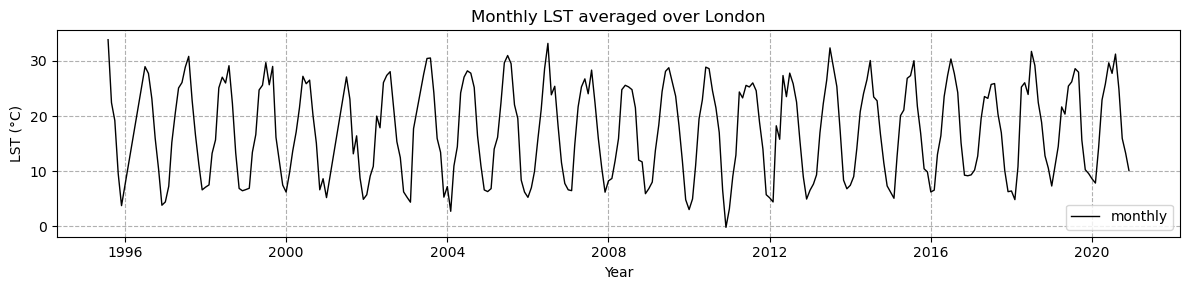

In [18]:
# Let's make our first plot of the computed yearly mean variable
# Plotting the global mean LST
fig = plt.figure(figsize=(12,3))
# Daily mean LST
(lst_LDN_mean_plot-273.15).plot(c='k',linewidth=1,label='monthly')
# Yearly mean LST
# Add the legend
plt.legend()
# Add a grid 
plt.grid(True, which='both',linestyle='--')
# Add a title and axis labels
plt.title('Monthly LST averaged over London')
plt.ylabel('LST (°C)')
plt.xlabel('Year')
#how to save the figure
#plt.savefig('Mean-LST-1995-2020.png')
plt.show()

In [19]:
#Now let's take a look at yearly mean LST , first we use the Toolbox again to compute the yearly mean:
resample_time = get_op('temporal_aggregation') #fetching the operator to temporally aggregate our data

lst_LDN_yr_mean  =resample_time(
    ds=lst_LDN_mean,
    method='mean',
    period='1YE'
) #note: it is also possible to use this operator for different periods, as well as computing maximum and minimum for a given period.


In [20]:
lst_LDN_yr_mean

<xarray.Dataset> Size: 1kB
Dimensions:   (time: 26, channel: 2, lat: 91, lon: 120)
Coordinates:
  * channel   (channel) float64 16B 11.0 12.0
  * lat       (lat) float32 364B 51.01 51.01 51.03 51.03 ... 51.88 51.9 51.9
  * lon       (lon) float32 480B -0.695 -0.685 -0.675 ... 0.475 0.485 0.495
  * time      (time) datetime64[ns] 208B 1995-12-31 1996-12-31 ... 2020-12-31
Data variables:
    lst_mean  (time) float64 208B dask.array<chunksize=(1,), meta=np.ndarray>
    lst_std   (time) float64 208B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes: (12/44)
    Conventions:                CF-1.8
    catalogue_url:              https://catalogue.ceda.ac.uk/uuid/6babb8d9a8d...
    cdm_data_type:              grid
    comment:                    These data were produced as part of the ESA L...
    creator_email:              djg20@le.ac.uk
    creator_name:               University of Leicester Surface Temperature G...
    ...                         ...
    time_coverage_end:          2020-12-31T00:00:00
    time_coverage_resolution:   P366D
    time_coverage_start:        1995-12-31T00:00:00
    title:                      ESA LST CCI land surface temperature time ser...
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-0.6999942064285278 51.0000038146972...

In [21]:
lst_LDN_yr_mean_plot = lst_LDN_yr_mean.lst_mean.compute()  

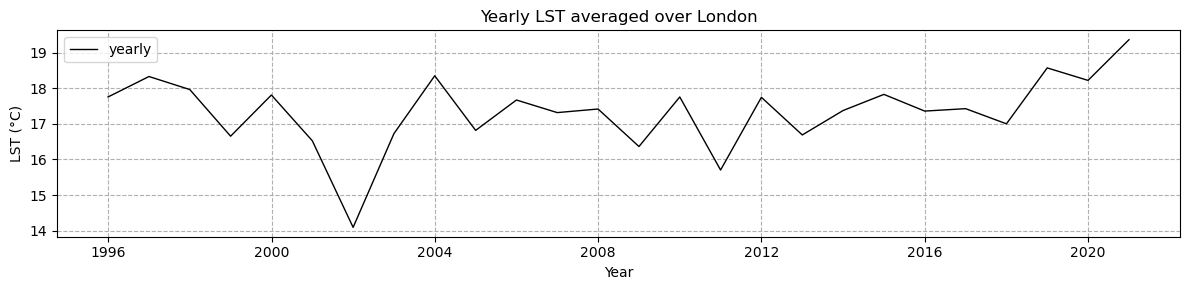

In [22]:
# Let's make our first plot of the computed yearly mean variable
# Plotting the global mean LST
fig = plt.figure(figsize=(12,3))
# Daily mean LST
(lst_LDN_yr_mean_plot-273.15).plot(c='k',linewidth=1,label='yearly')
# Yearly mean LST
# Add the legend
plt.legend()
# Add a grid 
plt.grid(True, which='both',linestyle='--')
# Add a title and axis labels
plt.title('Yearly LST averaged over London')
plt.ylabel('LST (°C)')
plt.xlabel('Year')
#how to save the figure
#plt.savefig('Mean-LST-1995-2020.png')
plt.show()

### Your turn: Let's explore a practical example with ECV data

### Evaluating Urban Heat Island Effect in London ###



During heatwaves, cities may experience more intense heat than rural areas due to the heat accumulation of buildings and streets, wind circulation and less vegetation. This phenomena is called Urban Heat Island (UHI). In this part, we will investigate the UHI effect in London.

 <div style="background-color: Gold ; padding: 10px; border-radius: 5px;">
👉 Task 1: Using the Toolbox functions, plot the map of LST data in London for July 2019, where an intense heatwave occured. Higlight King's College London and Aldbury on the map.
    <div >

To have more details on the functions and the arguments needed for your plots, you can check the following documentation:
https://esa-climate-toolbox.readthedocs.io/en/latest/api_reference.html#operations

In [23]:
#Type your code here
london_lat, london_lon = 51.511448, -0.116414 # Kings College 
ald_lat, ald_lon =  51.8, -0.6  #Aldbury

#...

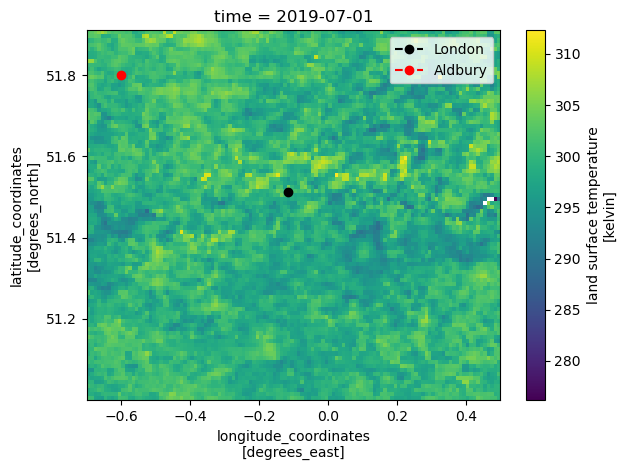

In [24]:
### Solution
time_slice="2019-07-01", "2019-07-01"
subset_temporal_op=get_op('subset_temporal')
lst_ds_sub_july=subset_temporal_op(ds=lst_ds_LDN,time_range=time_slice )
plot_op = get_op('plot')
plot(lst_ds_sub_july,
     var='lst', 
    indexers={'time': '2011-06-01'},  # Specify the date
    properties="cmap='viridis'") # Pass other properties here, such as color
london_lat, london_lon = 51.511448, -0.116414 # KC is 51.511448, and the longitude is -0.116414
stalb_lat, stalb_lon =  51.8, -0.6  #51.755001, and the longitude is -0.336000
plt.plot(london_lon, london_lat, linestyle='--', marker='o', color='k', label='London')
plt.plot(stalb_lon, stalb_lat, linestyle='--', marker='o', color='r', label='Aldbury')
#Aldbury ; Latitude · 51.800 ; Longitude · -0.600
plt.legend()


 <div style="background-color: Gold ; padding: 10px; border-radius: 5px;">
👉 Task 2: Compute the monthly LST climatogy, that is the mean over the months for 1995-2020 in London.
    <div >

For more information : https://esa-climate-toolbox.readthedocs.io/en/latest/api_reference.html#esa_climate_toolbox.ops.climatology

In [34]:
#Type your code here


In [25]:
#Solution
climatology_op = get_op('climatology')
lst_ds_clim = climatology_op(ds=lst_ds_LDN, var='lst')


<div style="background-color: Gold ; padding: 10px; border-radius: 5px;">
👉 Task 3:  

1. Open the Land Cover (LC) data set for 2015. You can use the data_id = 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-2015-v2.0.7b.zarr'
2. We want to look at LST for urban pixels and compare it to LST for non-urban pixels, for this, since LC and LST have different longitude and latitude dimensions, regrid LC data to the LST grid.
    <div >

In [35]:
#Type your code here


In [26]:
#Solution 1
from xcube.core.store import new_data_store
cci_zarr_store = new_data_store("esa-cci-zarr")
lc_ds = cci_zarr_store.open_data(
    'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-2015-v2.0.7b.zarr'
)
lc_ds_sub = subset_temporal_op(ds=lc_ds, time_range=['2015-07-03', '2015-07-03'])


In [ ]:
#Type your code here


In [27]:
#Solution 2
select_var_op = get_op('select_var')
lc_ds_sub = select_var_op(ds=lc_ds_sub, var="lccs_class")
normalize_op = get_op('normalize')
lc_ds_sub = normalize_op(ds=lc_ds_sub)

coregister_op = get_op('coregister')

downsampled_lc = coregister_op(
    ds_primary=lst_ds_sub_july,
    ds_replica=lc_ds_sub,
    method_ds="mode"
)
downsampled_lc

<xarray.Dataset> Size: 45kB
Dimensions:     (lat: 91, lon: 120, time: 1)
Coordinates:
  * lat         (lat) float32 364B 51.01 51.01 51.03 51.03 ... 51.88 51.9 51.9
  * lon         (lon) float32 480B -0.695 -0.685 -0.675 ... 0.475 0.485 0.495
  * time        (time) datetime64[ns] 8B 2015-07-03
Data variables:
    lccs_class  (time, lat, lon) float32 44kB dask.array<chunksize=(1, 91, 120), meta=np.ndarray>
Attributes: (12/40)
    Conventions:                CF-1.6
    TileSize:                   2048:2048
    catalogue_url:              https://catalogue.ceda.ac.uk/uuid/b382ebe6679...
    cdm_data_type:              grid
    comment:                    
    contact:                    landcover-cci@uclouvain.be
    ...                         ...
    time_coverage_start:        2015-07-03T00:00:00
    title:                      ESA CCI Land Cover Map
    tracking_id:                12590bad-9014-4a91-9048-d06b67965490
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-0.6999942064285278 51.0000038146972...

 <div style="background-color: Gold ; padding: 10px; border-radius: 5px;">
👉 Task 4: Plot the LC map in London for the year 2015. 
    <div >

In [ ]:
#Type your code here


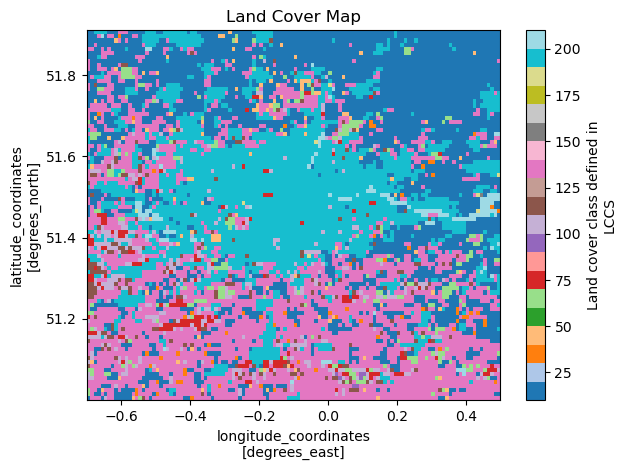

In [28]:
# Solution
plot_op(
    ds=downsampled_lc,           # Dataset variable (should be xarray.Dataset or DataArray)
    var='lccs_class',            # Variable name
    title="Land Cover Map",
    properties="cmap='tab20'"    # Choose a colormap suitable for categorical data
)

 <div style="background-color: Gold ; padding: 10px; border-radius: 5px;">
👉 (Optional Task): Create the LC map in London using the colormap of Land Cover. 
    <div >

For more information on the colour code, please refer to the [Product User Guide](https://climate.esa.int/media/documents/CCI_Land_Cover_PUG_v2.0.pdf). And for your convenience, we define it in the cell below. 

In [29]:
# Colour map:
from matplotlib.colors import ListedColormap, BoundaryNorm

#Define some simplified example LCCS classes (you can expand as needed)
class_ids = [10, 50, 100, 130, 150, 160, 190, 200, 210, 220]

class_names = [
    "Cropland",
    "Forest", 
    "Shrubland",
    "Grassland & Herbaceous",
    "Sparse Vegetation",
    "Wetlands",
    "Urban",
    "Bare Areas",
    "Water",
    "Snow/Ice"
]
colors = [
    "#ffff64", "#006400", "#8ca000", "#ffb432", "#ffebaf",
    "#00785a", "#c31400", "#fff5d7", "#0046c8", "#ffffff"
]

# Create colormap and normalization
cmap = ListedColormap(colors)

In [36]:
#Type your code here


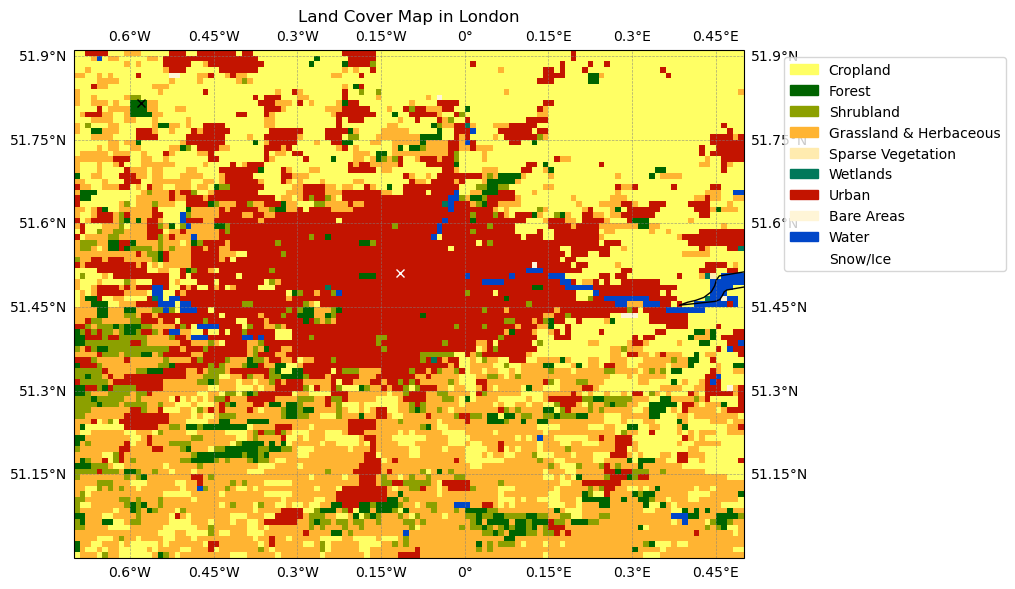

In [30]:
# Solution 
norm = BoundaryNorm(class_ids + [max(class_ids)+1], ncolors=cmap.N)
#Plot
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
img = downsampled_lc.lccs_class[0,:,:].plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)
ax.coastlines()
london_lat, london_lon = 51.511448, -0.116414 # KC is 51.511448, and the longitude is -0.116414
ald_lat, ald_lon =  51.815 , -0.58 #, and the longitude is -0.336000
plt.plot(london_lon, london_lat, linestyle='--', marker='x', color='white', label='Kings College')
plt.plot(ald_lon, ald_lat, linestyle='--', marker='x', color='k', label='Aldbury')
#Aldbury ; Latitude · 51.800 ; Longitude · -0.600

# Add lat/lon gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color="gray", alpha=0.7, linestyle="--")

ax.set_title("Land Cover Map in London")

# Add custom legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=colors[i], label=class_names[i]) for i in range(len(class_ids))]
plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()

 <div style="background-color: Gold ; padding: 10px; border-radius: 5px;">
👉 Task 5: We want to look at LST for urban pixels and compare it to LST for non-urban pixels, for this:

1. Since LC and LST have different longitude and latitude dimensions, regrid LC data to the LST grid.
2. Create a mask with urban pixels and non-urban pixels. Hint: the urban land cover pixels are coded with the number 190 which you can use for masking.
<div >

In [37]:
#Type your code here


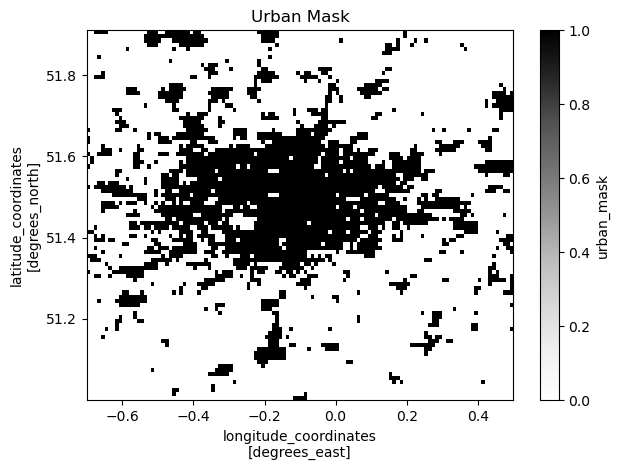

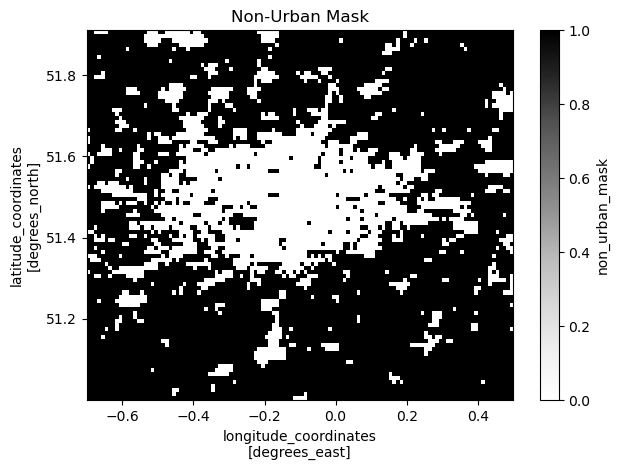

In [31]:
#Solution
#class_ids = [10, 50, 100, 130, 150, 160, 190, 200, 210, 220]
#[10, 50, 100, 130, 150, 160, 200, 220]
urban_mask = downsampled_lc['lccs_class'] == 190 # Boolean mask for urban points
urban_mask_da = urban_mask.astype(int).to_dataset(name="urban_mask")  # Convert to dataset with int values

# Apply the threshold to create the non-urban mask
non_urban_mask = ~urban_mask  # Invert the urban mask
non_urban_mask_da = non_urban_mask.astype(int).to_dataset(name="non_urban_mask")  # Convert to dataset with int values

# Apply the threshold to create another mask, f.i vegetation
#veg_mask =  downsampled_lc['lccs_class'] <= 50
#veg_mask_da =  veg_mask.astype(int).to_dataset(name="veg_mask")  # Convert to dataset with int values
# Plot the urban mask
plot_op(
    ds=urban_mask_da,          # Dataset variable
    var='urban_mask',          # Variable name
    title="Urban Mask",
    properties="cmap='Greys'"  # Use a greyscale colormap
)


# Plot the non-urban mask
plot_op(
    ds=non_urban_mask_da,      # Dataset variable
    var='non_urban_mask',      # Variable name
    title="Non-Urban Mask",
    properties="cmap='Greys'"  # Use a greyscale colormap
)


# Plot the vegetation max
#plot_op( ds=veg_mask_da,  var='veg_mask',     title="Veg Mask",  properties="cmap='Greys'"  )

 <div style="background-color: Gold ; padding: 10px; border-radius: 5px;">
👉 Task 6: Next, apply the urban and non-urban mask to LST data to plot:

1. The climatology of LST for urban pixels 
2. The climatology of LST for non-urban pixels

Highlight Aldbury and King's College London.
<div >

In [ ]:
#Type your code here


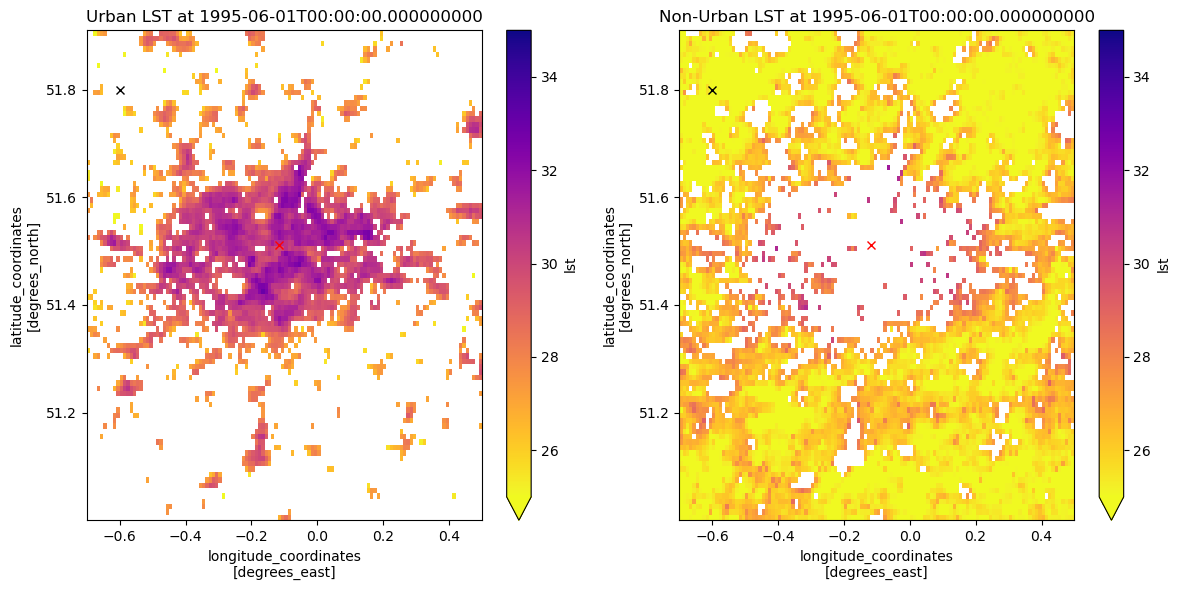

In [32]:
#Solution
lst_data_array = lst_ds_clim['lst']  # Replace 'lst' with the correct variable name

# Flip the urban_mask along the latitude axis
urban_mask_flipped = np.flipud(urban_mask)  # Flip along the vertical axis

# Apply the flipped mask to the LST data
urban_lst = xr.where(urban_mask_flipped, lst_data_array, np.nan)
non_urban_lst = xr.where(~urban_mask_flipped, lst_data_array, np.nan)

# Plot an example time step
time_step = lst_data_array.time[5]  # Choose the sixth time step for June
plt.figure(figsize=(12, 6))

# Plot Urban LST
plt.subplot(1, 2, 1)
(urban_lst-273.15).sel(time=time_step).plot(cmap="plasma_r",vmin=25, vmax = 35)
plt.title(f"Urban LST at {time_step.values}")
plt.plot(london_lon, london_lat, linestyle='--', marker='x', color='red', label='Kings College')
plt.plot(stalb_lon, stalb_lat, linestyle='--', marker='x', color='k', label='Aldbury')
# Plot Non-Urban LST
plt.subplot(1, 2, 2)
(non_urban_lst-273.15).sel(time=time_step).plot(cmap="plasma_r",vmin=25, vmax = 35)
plt.plot(london_lon, london_lat, linestyle='--', marker='x', color='red', label='Kings College')
plt.plot(stalb_lon, stalb_lat, linestyle='--', marker='x', color='k', label='Aldbury')
plt.title(f"Non-Urban LST at {time_step.values}")

plt.tight_layout()
plt.show()

 <div style="background-color: Gold ; padding: 10px; border-radius: 5px;">
👉 Task 7:  Plot the UHI over London. Hint: the UHI is defined as difference of LST between urban and rural areas. 
<div >

In [ ]:
#Type your code here


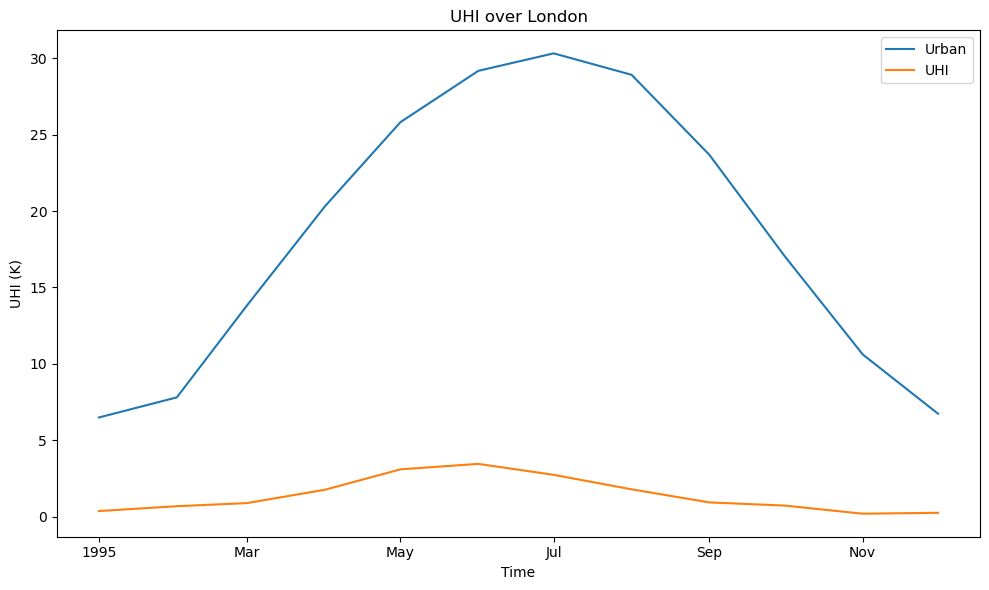

In [33]:
#Solution
#Compute the mean LST for urban and non-urban pixels over time
urban_mean = urban_lst.mean(dim=["lat", "lon"])
non_urban_mean = non_urban_lst.mean(dim=["lat", "lon"])
UHI = urban_mean - non_urban_mean 
# Plot the time series
plt.figure(figsize=(10, 6))
(urban_mean- 273.15).plot(label="Urban")
UHI.plot(label="UHI")
plt.title("UHI over London")
plt.ylabel("UHI (K)")
plt.xlabel("Time")
plt.legend()
plt.show()